In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Setup Path Direktori
BASE_DIR = r"D:\-\GEMASTIK 8"
DATASET_DIR = os.path.join(BASE_DIR, r"data\csiro-biomass")
RAW_IMG_DIR = os.path.join(DATASET_DIR, "train")
AUG_IMG_DIR = os.path.join(DATASET_DIR, "Augmentation_data")

ORIG_CSV = os.path.join(DATASET_DIR, "train.csv")
AUG_CSV = os.path.join(DATASET_DIR, "train_aug.csv")

In [6]:
# Load CSV
df_orig = pd.read_csv(ORIG_CSV)
df_aug = pd.read_csv(AUG_CSV)

# Hitung statistik
total_files_aug = len([f for f in os.listdir(AUG_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
expansion_factor = len(df_aug) / len(df_orig)

print("=" * 60)
print("📊 RINGKASAN STATISTIK DATASET AUGMENTASI & ENHANCEMENT")
print("=" * 60)
print(f"• Jumlah Baris CSV Asli (train.csv)     : {len(df_orig)} baris")
print(f"• Jumlah Baris CSV Baru (train_aug.csv) : {len(df_aug)} baris")
print(f"• Total File Gambar di Augmentation_data: {total_files_aug} file")
print(f"• Faktor Peningkatan Data               : {expansion_factor:.1f}x LIPAT 🚀")
print("=" * 60)

📊 RINGKASAN STATISTIK DATASET AUGMENTASI & ENHANCEMENT
• Jumlah Baris CSV Asli (train.csv)     : 1785 baris
• Jumlah Baris CSV Baru (train_aug.csv) : 17850 baris
• Total File Gambar di Augmentation_data: 3570 file
• Faktor Peningkatan Data               : 10.0x LIPAT 🚀


C:\Users\USER\AppData\Local\Temp\ipykernel_27424\3699702159.py:40: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_27424\3699702159.py:45: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig(output_plot_path, dpi=200, bbox_inches='tight')
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


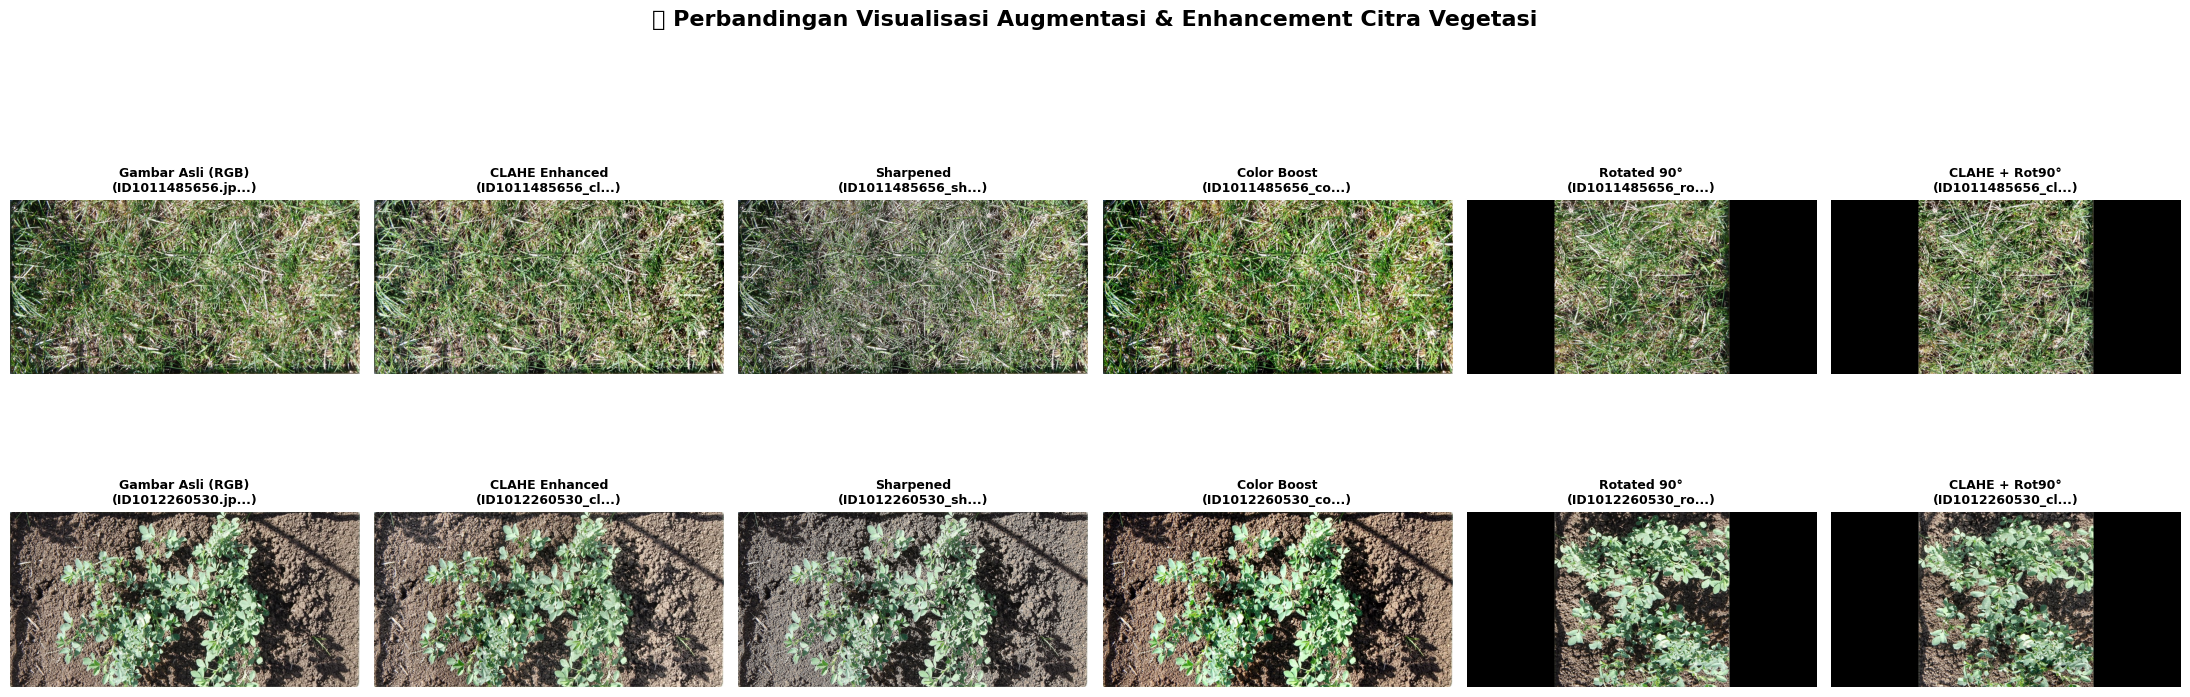


✓ Gambar preview visualisasi berhasil disimpan di: 'D:\-\GEMASTIK 8\outputs\preprocessing_augmentation_preview.png'


: 

In [ ]:
# Ambil 2 sampel gambar dari folder asli untuk diuji visualisasinya
sample_files = [f for f in os.listdir(RAW_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:2]

# Daftar variasi suffix yang dihasilkan oleh augment_dataset.py
variant_types = [
    ("", "Gambar Asli (RGB)"),
    ("_clahe", "CLAHE Enhanced"),
    ("_sharp", "Sharpened"),
    ("_color", "Color Boost"),
    ("_rot90", "Rotated 90°"),
    ("_clahe_rot90", "CLAHE + Rot90°")
]

fig, axes = plt.subplots(len(sample_files) * len(variant_types) // 6, 6, figsize=(22, 4 * len(sample_files)))

for idx, fname in enumerate(sample_files):
    name_no_ext, ext = os.path.splitext(fname)
    
    for v_idx, (suffix, title) in enumerate(variant_types):
        aug_filename = f"{name_no_ext}{suffix}{ext}"
        img_path = os.path.join(AUG_IMG_DIR, aug_filename)
        
        # Fallback ke folder asli jika variasi standar
        if not os.path.exists(img_path):
            img_path = os.path.join(RAW_IMG_DIR, fname)
            
        ax = axes[idx, v_idx] if len(sample_files) > 1 else axes[v_idx]
        
        if os.path.exists(img_path):
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{title}\n({aug_filename[:15]}...)", fontsize=9, fontweight='bold')
        else:
            ax.text(0.5, 0.5, "File Missing", ha='center', va='center')
            ax.set_title(title, fontsize=9, color='red')
            
        ax.axis('off')

plt.suptitle("📸 Perbandingan Visualisasi Augmentasi & Enhancement Citra Vegetasi", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan plot ke folder outputs
output_plot_path = os.path.join(BASE_DIR, r"outputs\preprocessing_augmentation_preview.png")
os.makedirs(os.path.dirname(output_plot_path), exist_ok=True)
plt.savefig(output_plot_path, dpi=200, bbox_inches='tight')

plt.show()
print(f"\n✓ Gambar preview visualisasi berhasil disimpan di: '{output_plot_path}'")